In [1]:
import pandas as pd
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')

])

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8544 - loss: 0.5018 - val_accuracy: 0.8791 - val_loss: 0.3764
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9505 - loss: 0.2948 - val_accuracy: 0.9231 - val_loss: 0.2516
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9505 - loss: 0.2023 - val_accuracy: 0.9231 - val_loss: 0.1976
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9670 - loss: 0.1524 - val_accuracy: 0.9341 - val_loss: 0.1657
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9643 - loss: 0.1214 - val_accuracy: 0.9451 - val_loss: 0.1487
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1004 - val_accuracy: 0.9451 - val_loss: 0.1391
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0862 - val_accuracy: 0.9451 - val_loss: 0.1313
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9835 - loss: 0.0762 - val_accuracy: 0.9451 - val_loss

In [8]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [9]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9736842105263158


In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  2]
 [ 1 70]]


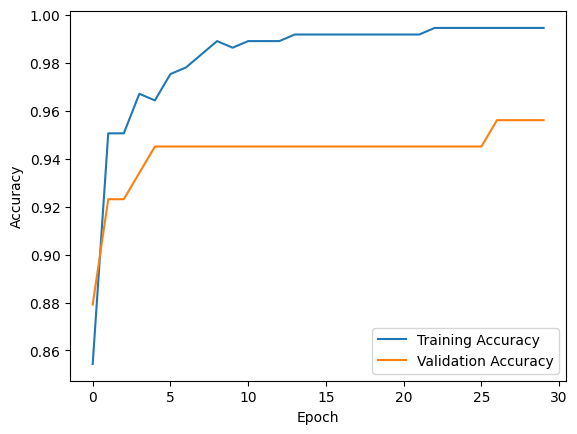

In [11]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()